# Atelier 1 — EDA véhicules et CO2

Ce notebook vise à comprendre la structure du catalogue de véhicules nettoyé.

L’objectif est d’examiner la qualité du dataset, les distributions, les corrélations, la concentration par famille et les risques de fuite ou de surreprésentation avant toute modélisation.

## 1. Chargement et nettoyage

Le fichier nettoyé contient des espaces parasites dans les noms de colonnes et dans certaines valeurs textuelles. Nous corrigeons cela dès le départ pour éviter d’introduire des biais dans les sélections et les agrégations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)

path = "../donnees_nettoyees/vehicules_analyse_conso_co2.csv"
df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()

for col in ["cnit", "lib_mrq_doss", "lib_mod_doss", "energ", "hybride", "typ_boite_nb_rapp"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df.head()

,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0
3,M10ALFVP000F303,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0
4,M10ALFVP000J306,ALFA ROMEO,159,GO,non,M 6,7,100.0,1615,1615,5.2,137.0


## 2. Dimensions, types et valeurs manquantes

Avant de modéliser, il faut vérifier la taille du dataset, les types de colonnes et la présence de valeurs nulles. Cela permet d’identifier les limites du dataset et d’éviter les erreurs logiques dans la suite.

In [2]:
print("shape:", df.shape)
print("\nTypes de colonnes:")
print(df.dtypes.to_string())
print("\nValeurs manquantes:")
print(df.isna().sum().sort_values(ascending=False).head(20).to_string())
print("\nAperçu:")
display(df.head(3))

shape: (20824, 12)

Types de colonnes:
cnit                     str
lib_mrq_doss             str
lib_mod_doss             str
energ                    str
hybride                  str
typ_boite_nb_rapp        str
puiss_admin            int64
puiss_max            float64
masse_ordma_min        int64
masse_ordma_max        int64
conso_mixte          float64
co2_mixte            float64

Valeurs manquantes:
cnit                 0
lib_mrq_doss         0
lib_mod_doss         0
energ                0
hybride              0
typ_boite_nb_rapp    0
puiss_admin          0
puiss_max            0
masse_ordma_min      0
masse_ordma_max      0
conso_mixte          0
co2_mixte            0

Aperçu:


,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0


## 3. Statistiques descriptives et distributions

Les variables techniques comme la puissance, la masse et l’émission de CO2 sont essentielles. Il faut aussi repérer les distributions aberrantes ou fortement asymétriques, car elles influencent le choix des méthodes et le besoin de transformation.

,count,mean,std,min,25%,50%,75%,max
puiss_admin,20824.0,12.42,9.75,2.0,8.0,9.0,12.0,80.0
puiss_max,20824.0,146.09,80.11,28.0,100.0,120.0,150.0,585.0
masse_ordma_min,20824.0,1810.74,371.72,875.0,1505.0,1760.0,2050.0,2765.0
masse_ordma_max,20824.0,1846.76,429.07,875.0,1508.0,1760.0,2050.0,3084.0
conso_mixte,20824.0,6.22,1.93,0.6,4.8,5.8,7.1,17.2
co2_mixte,20824.0,154.58,44.25,13.0,122.0,147.0,180.0,398.0


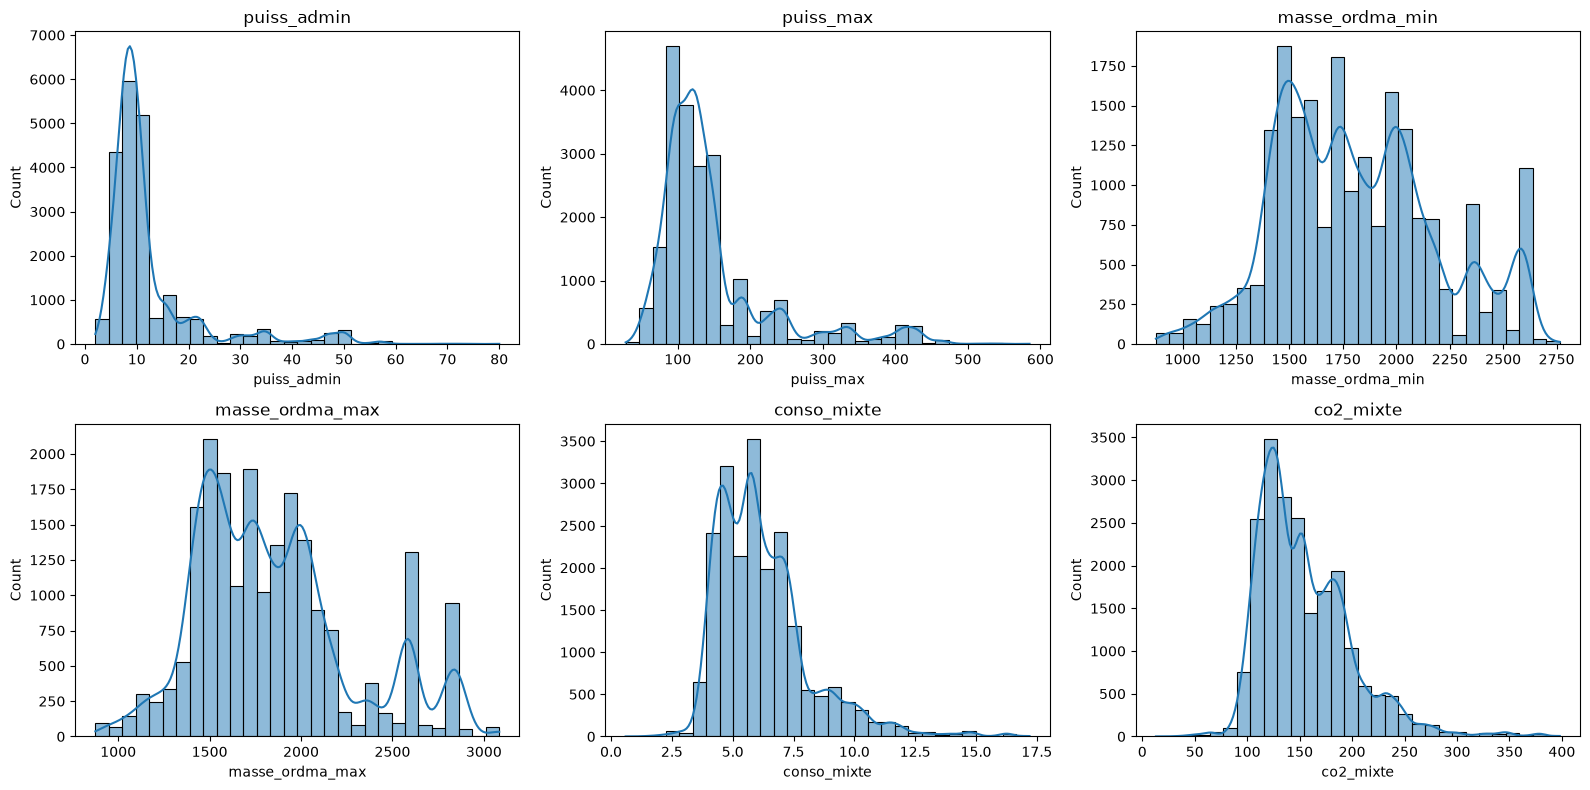

In [3]:
numeric_cols = [
    "puiss_admin", "puiss_max", "masse_ordma_min", "masse_ordma_max", "conso_mixte", "co2_mixte"
]
summary = df[numeric_cols].describe().T
display(summary.round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Concentration par famille

La fréquence par famille est un point critique dans ce jeu de données. Certaines familles et variantes sont très largement représentées, ce qui pèse directement sur la robustesse des splits et sur l’interprétation des clusters.

Nombre de familles distinctes : 444
Top 10 familles les plus fréquentes :
MERCEDES BENZ | CLASSE E      3044
MERCEDES BENZ | CLASSE C      2907
MERCEDES BENZ | SPRINTER      2697
MERCEDES BENZ | VITO          1026
MERCEDES BENZ | CLASSE S       980
MERCEDES BENZ | CLASSE V       846
MERCEDES BENZ | CLASSE CLA     503
MERCEDES BENZ | CLASSE B       442
MERCEDES BENZ | CLASSE A       354
MERCEDES BENZ | CLASSE CLS     346

Part cumulative des 10 familles les plus fréquentes : 63.12 %


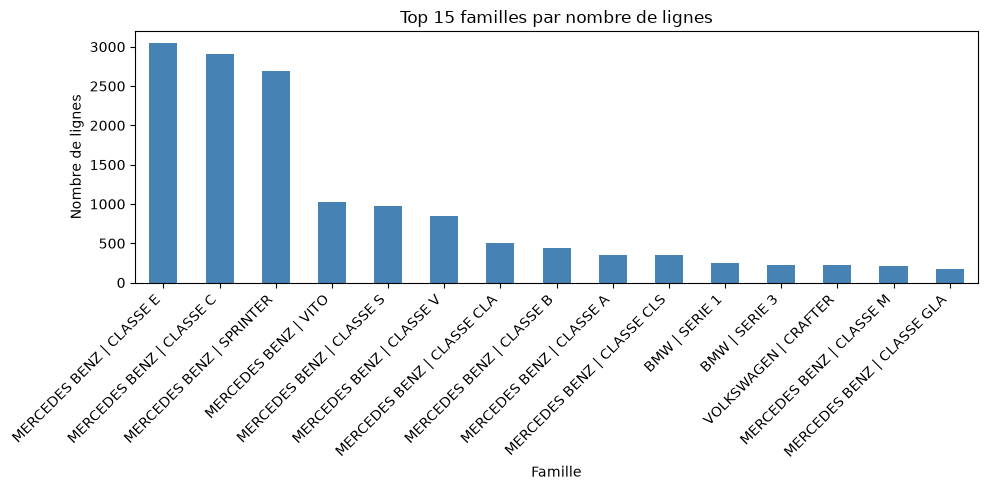

In [4]:
famille = df["lib_mrq_doss"].fillna("").astype(str) + " | " + df["lib_mod_doss"].fillna("").astype(str)
counts = famille.value_counts()
print("Nombre de familles distinctes :", famille.nunique())
print("Top 10 familles les plus fréquentes :")
print(counts.head(10).to_string())
print("\nPart cumulative des 10 familles les plus fréquentes :", round((counts.head(10).sum() / len(df)) * 100, 2), "%")

plt.figure(figsize=(10, 5))
counts.head(15).plot(kind="bar", color="steelblue")
plt.title("Top 15 familles par nombre de lignes")
plt.ylabel("Nombre de lignes")
plt.xlabel("Famille")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

> **À RÉDIGER (interprétation)** — Questions : (1) Quels sont les déséquilibres de famille et leurs conséquences ? (2) Quels risques cela fait-il pour le split train/test et le clustering ? (3) Quelles familles doivent être suivies avec attention ? — Chiffres à commenter : voir le tableau et la figure ci-dessus.

## 5. Corrélations et risques métier

Le CO2 est fortement lié à la consommation, à la puissance et à la masse. Ces relations ne sont pas des preuves de causalité, mais elles aident à choisir les variables pertinentes et à détecter les redondances avant la modélisation.

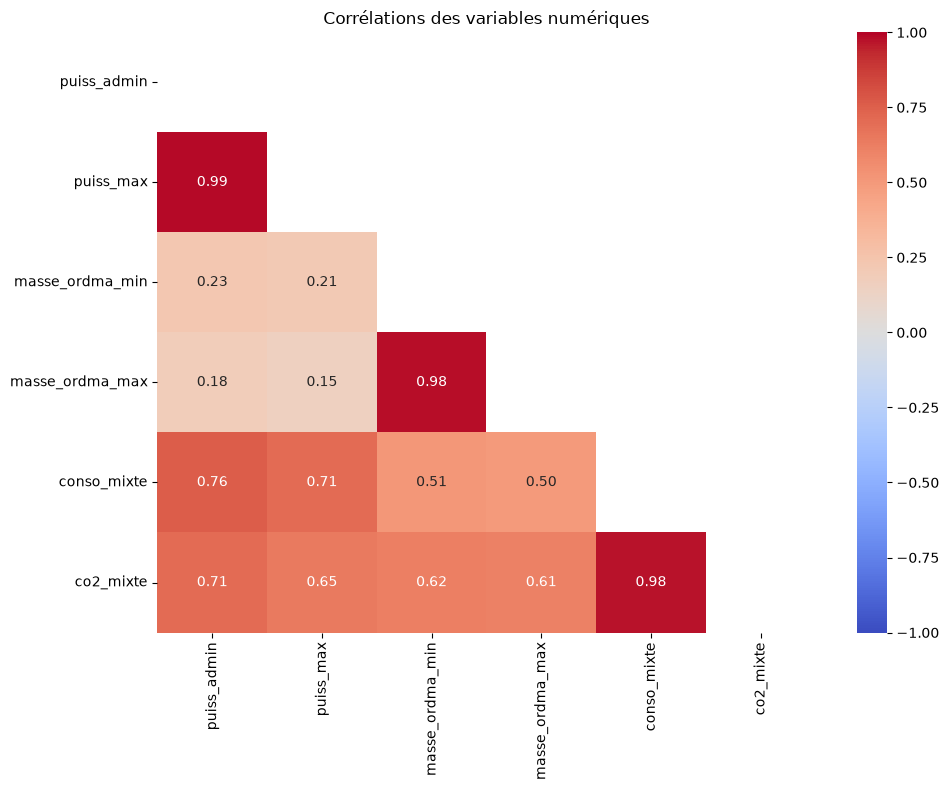

Données en double sur cnit : 61
Famille la plus fréquente : MERCEDES BENZ | CLASSE E avec 3044 lignes


In [5]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", mask=mask, vmin=-1, vmax=1)
plt.title("Corrélations des variables numériques")
plt.tight_layout()
plt.show()

print("Données en double sur cnit :", df["cnit"].duplicated().sum())
print("Famille la plus fréquente :", counts.idxmax(), "avec", counts.max(), "lignes")

> **À RÉDIGER (interprétation)** — Questions : (1) Quelles variables semblent les plus utiles pour la modélisation et pourquoi ? (2) Quels risques métier et méthodologiques découlent de la concentration par famille ? (3) Quelle décision de modélisation doit-on retenir à partir de cette analyse ? — Chiffres à commenter : voir la matrice de corrélation et les statistiques ci-dessus.